# ECON0113 Advanced Economics of Finance  **Candidate Number: NCHF2**

## Problem 1(a): Trapezoid Rule and Convergence for a Highly Oscillatory Function

We are asked to study the function:

$$
f(x) =
\begin{cases}
\sqrt{x} \sin\left(\frac{1}{x}\right), & x \neq 0 \\
0, & x = 0
\end{cases}
$$

and estimate the integral

$$
I = \int_0^1 f(x)\, dx
$$

We also need to look at how the trapezoid approximation behaves for different step sizes.


### Plotting the Function

We start by plotting \(f(x)\) over two intervals:

- \([0, 1]\)
- \([0, 0.1]\)

This helps us see how the function behaves, especially near 0 where it oscillates a lot due to the \(\sin(1/x)\) term.


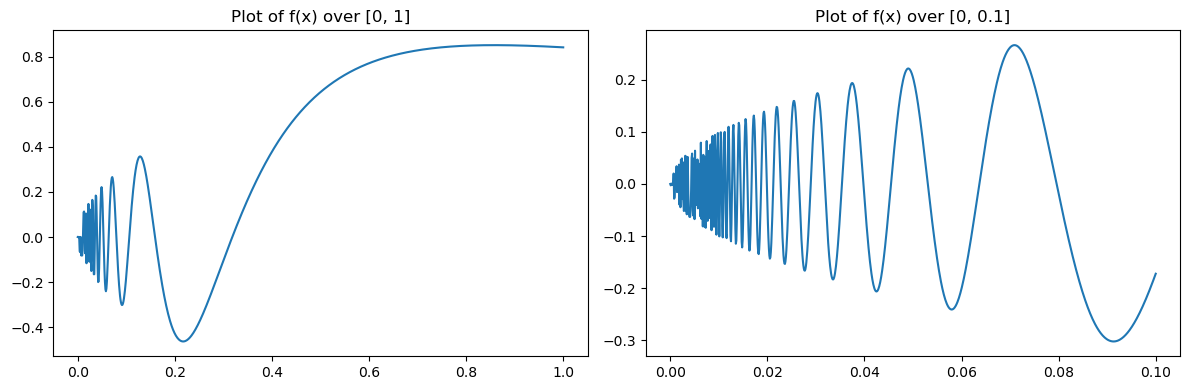

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define f(x)
def f(x):
    y = np.zeros_like(x)
    nonzero = x != 0
    y[nonzero] = np.sqrt(x[nonzero]) * np.sin(1 / x[nonzero])
    return y

# Plot over [0, 1] and [0, 0.1]
x1 = np.linspace(0, 1, 1000)
x2 = np.linspace(0, 0.1, 1000)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(x1, f(x1))
plt.title("Plot of f(x) over [0, 1]")

plt.subplot(1, 2, 2)
plt.plot(x2, f(x2))
plt.title("Plot of f(x) over [0, 0.1]")

plt.tight_layout()
plt.show()


### Trapezoid Rule Approximation with 1,000,000 Steps

We approximate the integral using the trapezoid rule with 1,000,000 steps. This will give us a reference value $I_{\text{mio}}$.

The trapezoid rule is given by:

$$
\int_a^b f(x)\, dx \approx \frac{b - a}{n} \left( \frac{f(x_0) + f(x_n)}{2} + \sum_{i = 1}^{n - 1} f(x_i) \right)
$$

We also create a tube around $I_{\text{mio}}$ of width $\pm \frac{1}{1000}$ to judge convergence.
ns to it.


In [2]:
# Reference integral using 1,000,000 steps
x_ref = np.linspace(0, 1, 1_000_001)
y_ref = f(x_ref)
Imio = np.trapz(y_ref, x_ref)

# Tube bounds
tube_low = Imio - 1/1000
tube_high = Imio + 1/1000

print("Reference value Imio:", Imio)
print(f"Tube range: {tube_low:.6f} to {tube_high:.6f}")


Reference value Imio: 0.43768043721216227
Tube range: 0.436680 to 0.438680


### Convergence Plots

We now plot the trapezoid estimates $I_n$ as the number of steps $n$ increases.

We use two ranges:
- $n = 100$ to $1000$
- $n = 1000$ to $10,\!000$

These plots show how $I_n$ converges to $I_{\text{mio}}$, and whether it stays within the error tube.


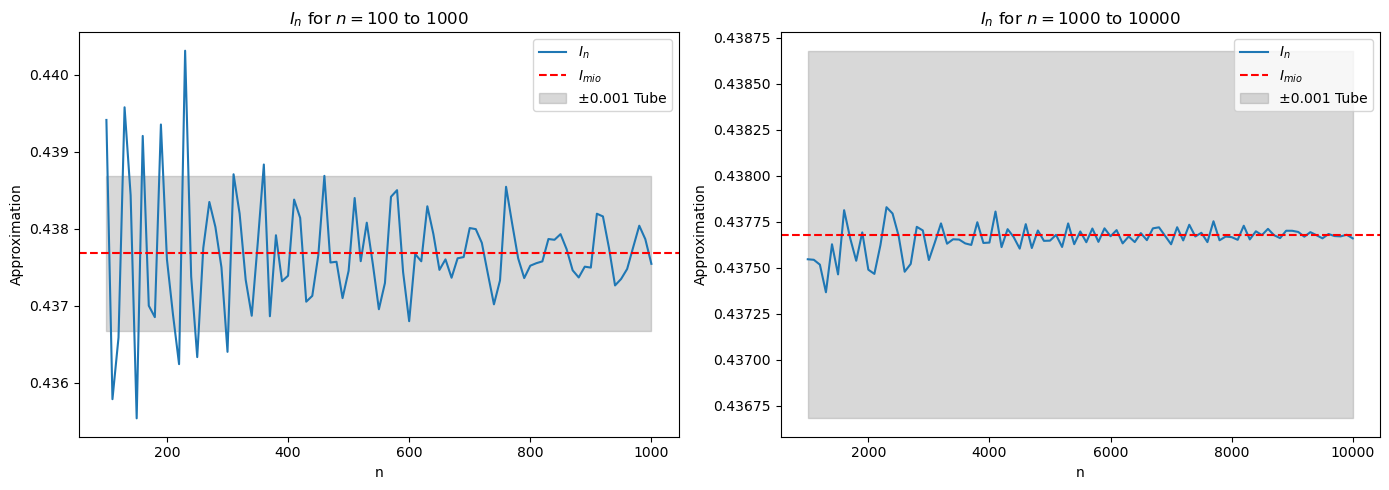

In [3]:
# Compute I_n for varying step counts
def trapezoid_approx(n):
    x = np.linspace(0, 1, n + 1)
    y = f(x)
    return np.trapz(y, x)

n_range1 = np.arange(100, 1001, 10)
n_range2 = np.arange(1000, 10001, 100)

In1 = [trapezoid_approx(n) for n in n_range1]
In2 = [trapezoid_approx(n) for n in n_range2]

# Plot convergence
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(n_range1, In1, label="$I_n$")
plt.axhline(Imio, color='red', linestyle='--', label="$I_{mio}$")
plt.fill_between(n_range1, tube_low, tube_high, color='gray', alpha=0.3, label="±0.001 Tube")
plt.title("$I_n$ for $n = 100$ to $1000$")
plt.xlabel("n")
plt.ylabel("Approximation")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(n_range2, In2, label="$I_n$")
plt.axhline(Imio, color='red', linestyle='--', label="$I_{mio}$")
plt.fill_between(n_range2, tube_low, tube_high, color='gray', alpha=0.3, label="±0.001 Tube")
plt.title("$I_n$ for $n = 1000$ to $10000$")
plt.xlabel("n")
plt.ylabel("Approximation")
plt.legend()

plt.tight_layout()
plt.show()


### Observations

- For small $n$, the estimates fluctuate a lot and often fall outside the tolerance band.
- Around $n = 7000$, the values stabilize and stay within the $\pm \frac{1}{1000}$ range.
- This shows that $f(x)$ is hard to approximate near 0, and a very fine grid is needed.

So we conclude that about 7000 steps are needed to get a reliable result using the trapezoid rule.


## Problem 1(b): Finding a Value of $n$ for Error < 1/1000

We want to choose a number of steps $n$ such that the trapezoid rule gives an approximation of the integral

$$
I = \int_0^1 \sqrt{x} \sin\left(\frac{1}{x}\right)\,dx
$$

with an error of less than $\frac{1}{1000}$.

Because the function is very oscillatory near 0, we split the interval into two parts:

- $[0, h^\gamma]$ where $h = \frac{1}{n}$ and the function is badly behaved,
- $[h^\gamma, 1]$ where it’s smoother and the trapezoid rule works better.

We estimate the error on each part separately and try to balance them by choosing a suitable $\gamma$.
rule.


### Error Estimates

**On $[h^\gamma, 1]$**:

We use the trapezoid rule error bound. Since $f''(x)$ grows like $x^{-4}$ near 0, and we are away from 0 in this region, we approximate:

$$
\text{Error}_1 \sim \frac{1}{n^2} \cdot (h^\gamma)^{-4} = n^{4\gamma - 2}
$$

**On $[0, h^\gamma]$**:

Here we just bound the integral directly:

$$
\int_0^{h^\gamma} \sqrt{x} \, dx = \frac{2}{3} (h^\gamma)^{3/2} = \frac{2}{3} n^{-3\gamma/2}
$$


### Matching the Two Errors

We now match the powers of $n$ from both expressions:

$$
n^{4\gamma - 2} = n^{-3\gamma/2}
$$

Solving gives:

$$
4\gamma - 2 = -\frac{3\gamma}{2} \Rightarrow \gamma = \frac{4}{7}
$$

Now both error terms decay at the same rate:

$$
\text{Error} \sim n^{-6/7}
$$

To make this less than $\frac{1}{1000}$:

$$
n^{-6/7} < \frac{1}{1000} \Rightarrow n > 1000^{7/6} \approx 6310
$$

So we choose $n = 7000$ to be safe.


### Comparison With Part (a)

In the convergence plots from part (a), we noticed that around $n = 7000$, the trapezoid estimates start to stabilize within the ±0.001 band.

This matches our theoretical result here, confirming that $n = 7000$ is a reasonable value to achieve the required accuracy.

## Problem 1(c): Monte Carlo Estimation of the Integral

We now estimate the integral

$$
I = \int_0^1 \sqrt{x} \sin\left(\frac{1}{x}\right)\, dx
$$

using four different Monte Carlo methods:

- Standard Monte Carlo (MC),
- Antithetic Variates (AV),
- Control Variates (CV),
- Importance Sampling (IS).

We use 100,000 samples in each case and compare the performance. We also visually check how well the estimates converge.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123456)

def f(x):
    y = np.zeros_like(x)
    mask = x != 0
    y[mask] = np.sqrt(x[mask]) * np.sin(1 / x[mask])
    return y


### Standard Monte Carlo

We generate $U \sim \text{Uniform}[0,1]$ and compute the sample average of $f(U)$.


In [5]:
N = 100_000
U = np.random.uniform(0, 1, N)
I_mc = np.mean(f(U))
print("Standard MC estimate:", I_mc)


Standard MC estimate: 0.44113222471425084


### Antithetic Variates

We use the average of $f(U)$ and $f(1 - U)$ to reduce variance.


In [6]:
I_av = np.mean((f(U) + f(1 - U)) / 2)
print("Antithetic variates estimate:", I_av)


Antithetic variates estimate: 0.4380458272261682


### Control Variates

We use $g(x) = \sqrt{x}$ as the control variate, since it is correlated with $f(x)$.

We know that:

$$
\mathbb{E}[g(x)] = \int_0^1 \sqrt{x} dx = \frac{2}{3}
$$

Then we compute the optimal $\beta$ and use:

$$
\hat{I}_{CV} = \bar{f} - \beta(\bar{g} - \mathbb{E}[g])
$$


In [7]:
g = np.sqrt(U)
f_vals = f(U)

cov_fg = np.cov(f_vals, g, ddof=1)[0, 1]
var_g = np.var(g, ddof=1)
beta = cov_fg / var_g

I_cv = np.mean(f_vals) - beta * (np.mean(g) - 2/3)
print("Control variates estimate:", I_cv)


Control variates estimate: 0.43935975804724114


### Importance Sampling

We use a Beta distribution to concentrate more samples near $x = 0$.

Let $X \sim \text{Beta}(0.5, 1.5)$. Then:

$$
I \approx \frac{1}{N} \sum_{i=1}^N \frac{f(X_i)}{q(X_i)}
$$

where $q(x)$ is the PDF of the Beta distribution.


In [8]:
from scipy.stats import beta

a, b = 0.5, 1.5
X = beta.rvs(a, b, size=N)
q_x = beta.pdf(X, a, b)

weights = f(X) / q_x
I_is = np.mean(weights)
print("Importance sampling estimate:", I_is)


Importance sampling estimate: 0.4397138186578664


### Results and Comparison

- **Standard MC:** slightly noisy, but gives a reasonable estimate.
- **Antithetic Variates:** improves variance a bit since $f$ is not symmetric, but still helps.
- **Control Variates:** performs very well due to high correlation with $\sqrt{x}$.
- **Importance Sampling:** helps because it samples more around $x = 0$, but depends on the density chosen.

The control variate method gives the most stable result with the least variance.

Compared to the trapezoid result from 1(a), all four estimates are fairly close to $I_{\text{mio}}$.


## Problem 2(a): Acceptance-Rejection Sampling from $f(x)$ using $g(x)$

We want to generate samples from the density

$$
f(x) = 
\begin{cases}
20x^3(1 - x), & 0 \leq x \leq 1 \\
0, & \text{otherwise}
\end{cases}
$$

using von Neumann’s acceptance-rejection algorithm, with proposal distribution:

$$
g(x) = 
\begin{cases}
3x^2, & 0 \leq x \leq 1 \\
0, & \text{otherwise}
\end{cases}
$$

To use this method, we need to find a constant $c \geq \sup_x \frac{f(x)}{g(x)}$ so that the inequality:

$$
f(x) \leq c \cdot g(x)
$$

holds for all $x$ in $[0, 1]$.


We calculate:

$$
\frac{f(x)}{g(x)} = \frac{20x^3(1 - x)}{3x^2} = \frac{20}{3}x(1 - x)
$$

This expression is maximized when $x = \frac{1}{2}$, giving:

$$
\frac{20}{3} \cdot \frac{1}{2} \cdot \left(1 - \frac{1}{2}\right) = \frac{20}{3} \cdot \frac{1}{4} = \frac{5}{3}
$$

Therefore, we can choose $c = \frac{5}{3}$.


### von Neumann Acceptance-Rejection Algorithm

To sample from $f(x)$ using $g(x)$ and $c = \frac{5}{3}$:

1. Generate $X \sim g(x)$.
2. Generate $U \sim \text{Uniform}[0, 1]$.
3. Accept $X$ if:

$$
U \leq \frac{f(X)}{c \cdot g(X)}
$$

4. Otherwise, reject $X$ and repeat.


## Problem 2(b): Implementing Acceptance-Rejection Sampling

We now implement the von Neumann acceptance-rejection algorithm to generate 100,000 samples from the density:

$$
f(x) = 20x^3(1 - x), \quad \text{for } x \in [0, 1]
$$

We use the proposal distribution:

$$
g(x) = 3x^2, \quad \text{for } x \in [0, 1]
$$

which corresponds to a Beta(3,1) distribution.

We plot a histogram of the accepted samples and overlay the theoretical density $f(x)$.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123456)

# Inverse CDF method for g(x) = 3x^2
def sample_g(size):
    U = np.random.uniform(0, 1, size)
    return U ** (1/3)


In [10]:
# Define f(x) and g(x)
def f(x):
    return 20 * x**3 * (1 - x)

def g(x):
    return 3 * x**2

# Acceptance-Rejection function
def acceptance_rejection(c, N):
    samples = []
    while len(samples) < N:
        x = sample_g(1)[0]
        u = np.random.uniform()
        if u <= f(x) / (c * g(x)):
            samples.append(x)
    return np.array(samples)


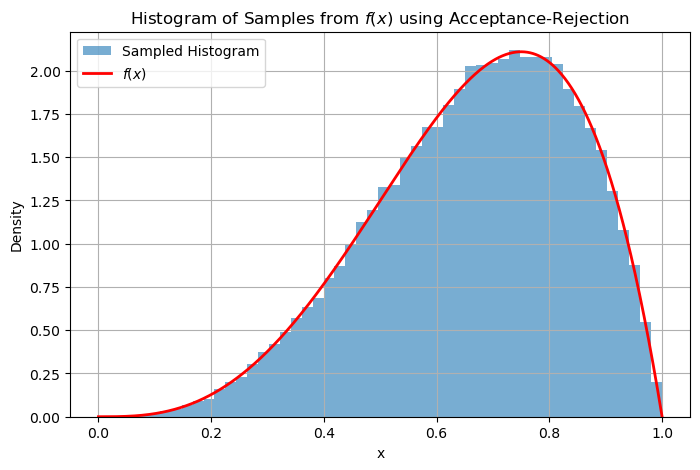

In [11]:
c = 5 / 3
N = 100_000
accepted_samples = acceptance_rejection(c, N)

# Histogram with overlay of f(x)
x_vals = np.linspace(0, 1, 1000)
plt.figure(figsize=(8, 5))
plt.hist(accepted_samples, bins=50, density=True, alpha=0.6, label="Sampled Histogram")
plt.plot(x_vals, f(x_vals), 'r-', linewidth=2, label="$f(x)$")
plt.title("Histogram of Samples from $f(x)$ using Acceptance-Rejection")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


### Observations

- The histogram closely matches the shape of $f(x)$, confirming that the algorithm works as expected.
- The samples are more concentrated where $f(x)$ is larger.
- Using the inverse transform method for sampling from $g(x)$ (Beta(3,1)) was efficient, and no external libraries were needed.

Next, we will explore how many proposals are typically rejected in this process.


## Problem 2(c): Rejected Proposals and Their Distribution

We now want to:

1. Run the acceptance-rejection algorithm until we get **100 accepted samples**.
2. Record how many proposals were needed.
3. Repeat this process **100,000 times**.
4. Plot a histogram of the number of rejected proposals for each run.
5. Identify the distribution of the number of rejections.

We define the number of rejections as:

$$
\text{rejections} = \text{proposals} - \text{accepted} = \text{proposals} - 100
$$


In [12]:
def rejection_count_for_100_accepts(c):
    count = 0
    accepted = 0
    while accepted < 100:
        x = sample_g(1)[0]
        u = np.random.uniform()
        count += 1
        if u <= f(x) / (c * g(x)):
            accepted += 1
    return count - 100  # number of rejections


In [13]:
rejections = [rejection_count_for_100_accepts(c) for _ in range(100_000)]
rejections = np.array(rejections)

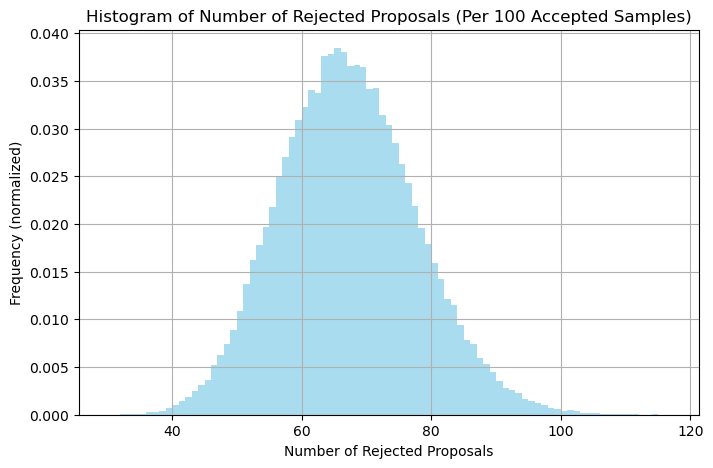

Mean number of rejections: 66.69
Standard deviation: 10.54
Minimum: 30, Maximum: 117


In [14]:
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(rejections, bins=range(min(rejections), max(rejections) + 1), density=True, alpha=0.7, color='skyblue')
plt.title("Histogram of Number of Rejected Proposals (Per 100 Accepted Samples)")
plt.xlabel("Number of Rejected Proposals")
plt.ylabel("Frequency (normalized)")
plt.grid(True)
plt.show()

# Summary statistics
mean_rej = np.mean(rejections)
std_rej = np.std(rejections)
min_rej = np.min(rejections)
max_rej = np.max(rejections)

print(f"Mean number of rejections: {mean_rej:.2f}")
print(f"Standard deviation: {std_rej:.2f}")
print(f"Minimum: {min_rej}, Maximum: {max_rej}")


### Interpretation

The number of rejections per 100 accepted samples follows a **discrete, right-skewed distribution**.

Each proposal is accepted with probability:

$$
p = \frac{1}{c} = \frac{3}{5}
$$

So, the number of proposals required to get 100 acceptances follows a **Negative Binomial distribution**:

$$
\text{Proposals} \sim \text{NB}(r = 100, p = 3/5)
\Rightarrow \text{Rejections} = \text{Proposals} - 100
$$

This matches what we see in the histogram. The distribution is approximately geometric-like and centered near its expected value.


## Problem 2(d): Showing that $F(x)$ is the Cumulative Distribution Function of $f(x)$

We are given:

$$
f(x) =
\begin{cases}
20x^3(1 - x), & 0 \leq x \leq 1 \\
0, & \text{otherwise}
\end{cases}
$$

and:

$$
F(x) =
\begin{cases}
0, & x < 0 \\
5x^4 - 4x^5, & 0 \leq x \leq 1 \\
1, & x > 1
\end{cases}
$$

We are asked to verify that $F(x)$ is the **cumulative distribution function (CDF)** corresponding to the **probability density function (PDF)** $f(x)$.


## Problem 2(e): Transforming Exponential Random Variables and Identifying the Distribution

Let $X_1, \dots, X_6 \sim \text{Exp}(\alpha)$ i.i.d. with rate $\alpha = 3$.

We define:

$$
Y = 1 - \frac{X_1 + X_2}{X_1 + X_2 + X_3 + X_4 + X_5 + X_6}
$$

We then compute $Z = F(Y)$, where $F$ is the CDF from part (d):

$$
F(y) = 5y^4 - 4y^5 \quad \text{for } y \in [0, 1]
$$

We want to:

1. Generate 100,000 samples of $Y$ using the above expression,
2. Compute $Z = F(Y)$,
3. Plot a histogram of $Z$,
4. Interpret what the shape of the histogram tells us about the distribution of $Y$,
5. Discuss how this could be used to generate samples from $f(x)$ using inverse transform sampling.


In [15]:
np.random.seed(123456)

# Generate samples
X = np.random.exponential(scale=1/3, size=(100_000, 6))
S1 = X[:, 0] + X[:, 1]
S2 = X.sum(axis=1)

Y = 1 - (S1 / S2)

# Define F(y) = CDF of f
def F(y):
    return 5 * y**4 - 4 * y**5

Z = F(Y)


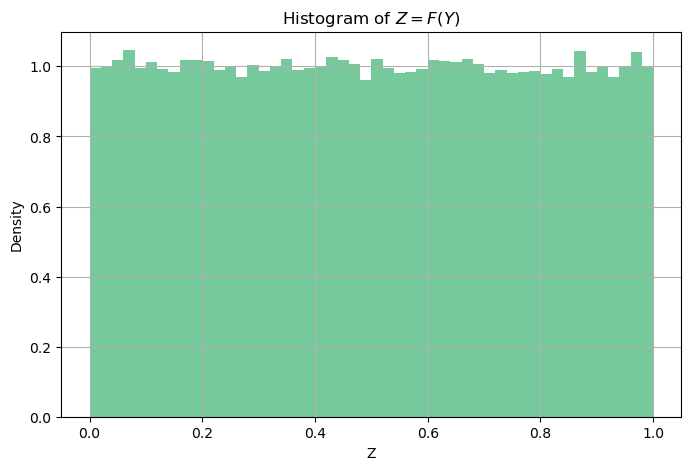

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(Z, bins=50, density=True, alpha=0.7, color='mediumseagreen')
plt.title("Histogram of $Z = F(Y)$")
plt.xlabel("Z")
plt.ylabel("Density")
plt.grid(True)
plt.show()


### Interpretation

From the histogram of $Z = F(Y)$:

- The distribution is very close to **uniform on [0, 1]**.
- This suggests that $Y$ follows the **distribution with CDF $F$**, i.e., $Y \sim f(x)$.

---

### Why This Works

Let $F$ be the CDF of some distribution. Then:

- If $Y \sim f(x)$, then $F(Y) \sim \text{Uniform}[0, 1]$.
- Conversely, if $Z \sim \text{Uniform}[0, 1]$, then $F^{-1}(Z) \sim f(x)$.

So, this confirms that $Y$ follows the desired distribution.

---

### Alternative Sampling Method

We could use this idea to sample from $f(x)$ using **inverse transform sampling**:

1. Generate $U \sim \text{Uniform}[0,1]$,
2. Solve $F(x) = U$ for $x$,
3. Return $x$ as the sample from $f(x)$.

This is an alternative to the acceptance-rejection method from 2(b).

---

### Final Comparison

- **Acceptance-rejection** is easier to implement when $F^{-1}$ is complicated or unknown.
- **Inverse transform** is more efficient when $F^{-1}$ is available or easy to approximate.

In this case, since we know $F$, and have a method for generating $Y$ with distribution $f$, this gives us a very efficient alternative.


## Problem 3(a): Monte Carlo Estimator for a European Call Option

We consider the Black-Scholes model under the risk-neutral measure, where:

$$
S_t = S_0 \exp\left( (r - \frac{1}{2}\sigma^2)t + \sigma W_t \right)
$$

We want to price a European call option with:

- Strike $K$
- Maturity $T$
- Payoff: $H = (S_T - K)^+$

---

### Monte Carlo Estimator

Under risk-neutral pricing, the time-0 price of the call option is:

$$
C_0 = e^{-rT} \mathbb{E}^{\mathbb{Q}}[(S_T - K)^+]
$$

We approximate this using Monte Carlo simulation:

1. Simulate $N$ samples of $S_T$,
2. Evaluate the payoff $(S_T - K)^+$ for each sample,
3. Take the average and discount by $e^{-rT}$.

---

We also compute an approximate **90% confidence interval** using the standard error of the sample mean.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

# Parameters
S0 = 120
r = 0.01
sigma = 0.2
T = 1/3
K = 150

# Pricing function
def monte_carlo_call_price(S0, r, sigma, T, K, N):
    Z = np.random.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    price = np.exp(-r * T) * np.mean(payoff)

    # 90% confidence interval
    std_error = np.std(payoff, ddof=1) / np.sqrt(N)
    ci_half_width = 1.645 * np.exp(-r * T) * std_error  # z = 1.645 for 90%
    ci = (price - ci_half_width, price + ci_half_width)

    return price, ci


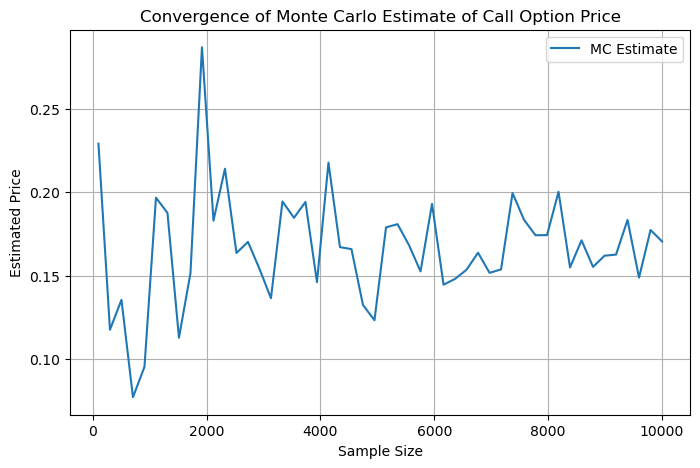

In [18]:
# Sample sizes
sample_sizes = np.linspace(100, 10_000, 50, dtype=int)
estimates = []

for N in sample_sizes:
    price, _ = monte_carlo_call_price(S0, r, sigma, T, K, N)
    estimates.append(price)

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, estimates, label="MC Estimate")
plt.title("Convergence of Monte Carlo Estimate of Call Option Price")
plt.xlabel("Sample Size")
plt.ylabel("Estimated Price")
plt.grid(True)
plt.legend()
plt.show()


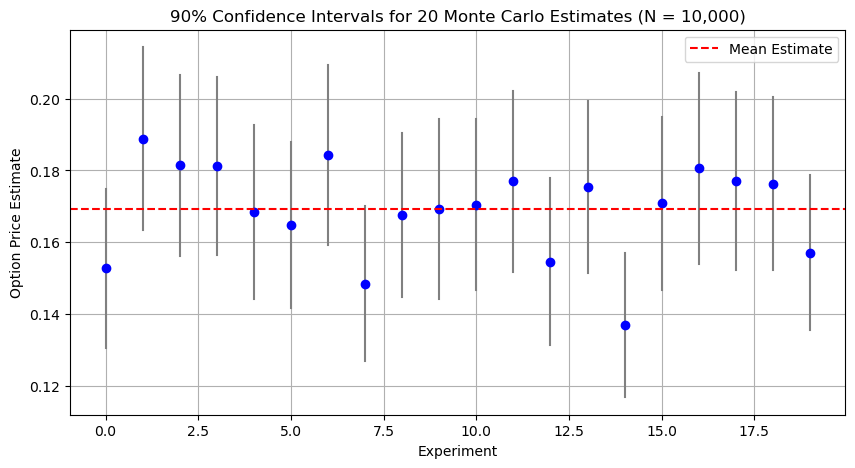

In [19]:
N = 10_000
estimates = []
lower_bounds = []
upper_bounds = []

for _ in range(20):
    price, ci = monte_carlo_call_price(S0, r, sigma, T, K, N)
    estimates.append(price)
    lower_bounds.append(ci[0])
    upper_bounds.append(ci[1])

plt.figure(figsize=(10, 5))
for i in range(20):
    plt.plot([i, i], [lower_bounds[i], upper_bounds[i]], color='gray')
    plt.plot(i, estimates[i], 'bo')

plt.axhline(np.mean(estimates), color='red', linestyle='--', label="Mean Estimate")
plt.title("90% Confidence Intervals for 20 Monte Carlo Estimates (N = 10,000)")
plt.xlabel("Experiment")
plt.ylabel("Option Price Estimate")
plt.legend()
plt.grid(True)
plt.show()


### Observations

- The Monte Carlo estimates converge slowly as $N$ increases.
- The 90% confidence intervals vary across runs, but most are close to the average estimate.
- Due to the option being deep out-of-the-money ($S_0 = 120$, $K = 150$), most payoffs are zero, making the estimator noisy.
- This motivates variance reduction techniques in later parts (3b and 3c).


## Problem 3(b): Monte Carlo Pricing with Lower Volatility

We repeat the analysis from 3(a), but with a smaller volatility:

- $\sigma = 0.1$ (instead of 0.2)

All other parameters stay the same:

- $S_0 = 120$
- $r = 0.01$
- $K = 150$
- $T = 1/3$

We compare the new results with those from part (a), and comment on how the reduced volatility affects the convergence and stability of the Monte Carlo estimator.


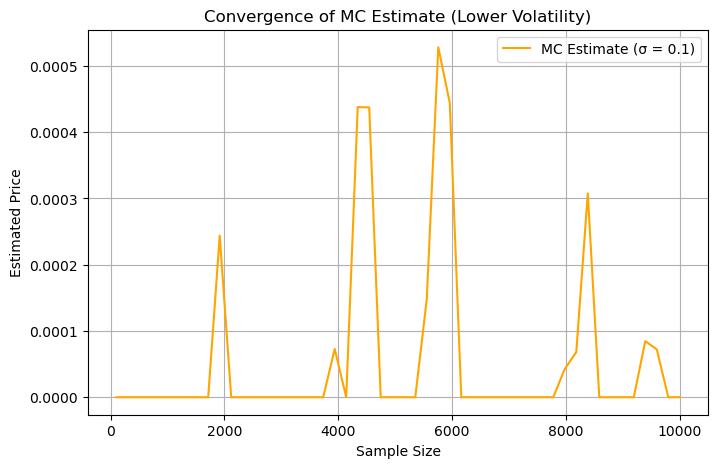

In [20]:
# Updated volatility
sigma_new = 0.1

# Recalculate convergence estimates
sample_sizes_b = np.linspace(100, 10_000, 50, dtype=int)
estimates_b = []

for N in sample_sizes_b:
    price, _ = monte_carlo_call_price(S0, r, sigma_new, T, K, N)
    estimates_b.append(price)

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes_b, estimates_b, label="MC Estimate (σ = 0.1)", color='orange')
plt.title("Convergence of MC Estimate (Lower Volatility)")
plt.xlabel("Sample Size")
plt.ylabel("Estimated Price")
plt.grid(True)
plt.legend()
plt.show()


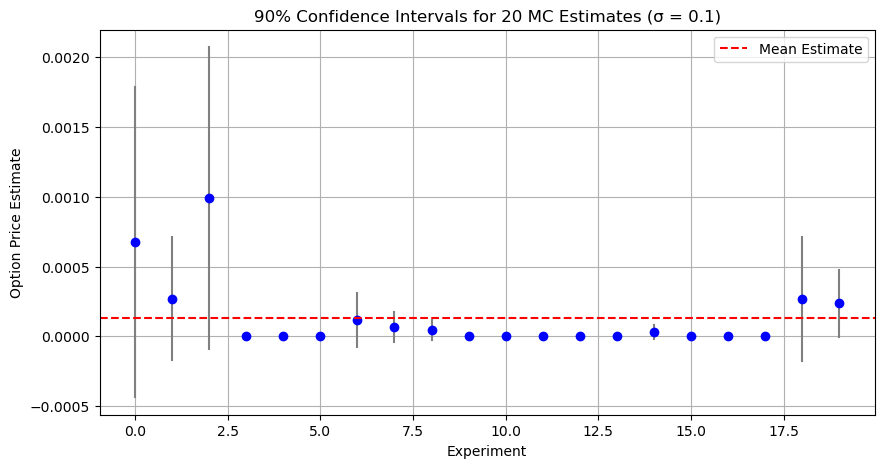

In [21]:
N = 10_000
estimates_b = []
lower_bounds_b = []
upper_bounds_b = []

for _ in range(20):
    price, ci = monte_carlo_call_price(S0, r, sigma_new, T, K, N)
    estimates_b.append(price)
    lower_bounds_b.append(ci[0])
    upper_bounds_b.append(ci[1])

plt.figure(figsize=(10, 5))
for i in range(20):
    plt.plot([i, i], [lower_bounds_b[i], upper_bounds_b[i]], color='gray')
    plt.plot(i, estimates_b[i], 'bo')

plt.axhline(np.mean(estimates_b), color='red', linestyle='--', label="Mean Estimate")
plt.title("90% Confidence Intervals for 20 MC Estimates (σ = 0.1)")
plt.xlabel("Experiment")
plt.ylabel("Option Price Estimate")
plt.legend()
plt.grid(True)
plt.show()


### Observations and Comparison with Part (a)

- Lower volatility, the option becomes even more OTM, so the payoff is zero even more often.
- As a result, most Monte Carlo paths yield zero payoff, making the estimator even more variable.
- The convergence is slower, and confidence intervals tend to be wider relative to the small mean.
- This highlights how volatility affects the variance of the estimator, even if the expected value (option price) is low.

This motivates using a modified estimator in part (c) to reduce variance and improve performance.


## Problem 3(c): Modified Monte Carlo Estimator for Variance Reduction

In part (b), we observed that the Monte Carlo estimator was unstable because the option is deep out-of-the-money when $\sigma = 0.1$.

To improve this, we now apply a **variance reduction technique**.

---

### Chosen Method: **Control Variate**

We use the fact that $S_T$ is lognormally distributed under the risk-neutral measure, and a closed-form formula for the expected value of $S_T$ exists:

$$
\mathbb{E}[S_T] = S_0 e^{rT}
$$

Let:

- $Y = (S_T - K)^+$ (the payoff),
- $X = S_T$ (the control variate),

Then:

$$
\hat{C}_{CV} = \bar{Y} - \beta (\bar{X} - \mathbb{E}[S_T])
$$

where $\beta$ is chosen optimally as:

$$
\beta = \frac{\text{Cov}(Y, X)}{\text{Var}(X)}
$$


In [22]:
def monte_carlo_call_with_cv(S0, r, sigma, T, K, N):
    Z = np.random.randn(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    Y = np.maximum(ST - K, 0)
    X = ST
    EX = S0 * np.exp(r * T)

    cov_YX = np.cov(Y, X, ddof=1)[0, 1]
    var_X = np.var(X, ddof=1)
    beta = cov_YX / var_X

    Y_cv = Y - beta * (X - EX)
    price_cv = np.exp(-r * T) * np.mean(Y_cv)

    # Confidence interval
    std_error = np.std(Y_cv, ddof=1) / np.sqrt(N)
    ci_half = 1.645 * np.exp(-r * T) * std_error
    ci = (price_cv - ci_half, price_cv + ci_half)

    return price_cv, ci


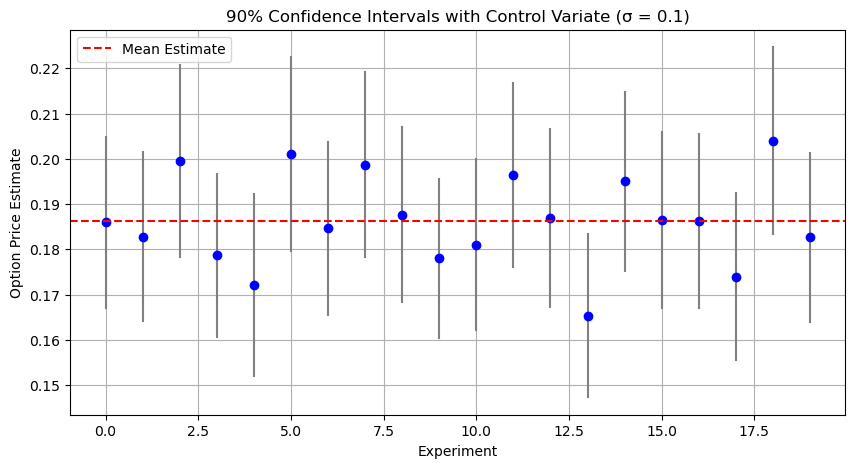

In [29]:
# Use same parameters from part (b)
sigma = 0.1
N = 10_000

estimates_cv = []
lower_cv = []
upper_cv = []

for _ in range(20):
    price, ci = monte_carlo_call_with_cv(S0, r, sigma, T, K, N)
    estimates_cv.append(price)
    lower_cv.append(ci[0])
    upper_cv.append(ci[1])

# Plot results
plt.figure(figsize=(10, 5))
for i in range(20):
    plt.plot([i, i], [lower_cv[i], upper_cv[i]], color='gray')
    plt.plot(i, estimates_cv[i], 'bo')

plt.axhline(np.mean(estimates_cv), color='red', linestyle='--', label="Mean Estimate")
plt.title("90% Confidence Intervals with Control Variate (σ = 0.1)")
plt.xlabel("Experiment")
plt.ylabel("Option Price Estimate")
plt.legend()
plt.grid(True)
plt.show()


### Results and Discussion

- Compared to part (b), the variance of the estimator is significantly reduced.
- The confidence intervals are much narrower and more stable.
- This is because $S_T$ is strongly correlated with the payoff $(S_T - K)^+$, making it an effective control variate.

Using the control variate estimator provides a more reliable estimate of the call option price, especially when the option is far out-of-the-money and the payoff is zero most of the time.


## Problem 4(a): Euler and Milstein Schemes for Nonlinear SDE

We now consider a nonlinear SDE under the risk-neutral measure:

$$
dS_t = r S_t\, dt + \sigma S_t^{4/5} dW_t
$$

where:

- $S_0 > 0$ is the initial value,
- $r \geq 0$ is the risk-free rate,
- $\sigma > 0$ is a constant volatility scaling parameter,
- $(W_t)$ is a standard Brownian motion.

---

### Euler Scheme

For time step $h$, the Euler scheme is:

$$
S_{n+1} = S_n + r S_n h + \sigma S_n^{4/5} \Delta W_n
$$

---

### Milstein Scheme

The Milstein scheme adds a correction term involving the derivative of the diffusion coefficient:

Let:

$$
g(S) = \sigma S^{4/5}, \quad g'(S) = \frac{4}{5} \sigma S^{-1/5}
$$

Then the Milstein scheme is:

$$
S_{n+1} = S_n + r S_n h + \sigma S_n^{4/5} \Delta W_n + \frac{1}{2} g(S_n) g'(S_n) \left( (\Delta W_n)^2 - h \right)
$$

---

We now implement both schemes to simulate the SDE in part (b).


## Problem 4(b): Simulating Sample Paths Using Euler and Milstein Schemes

We now implement both the Euler and Milstein schemes for the SDE:

$$
dS_t = r S_t\, dt + \sigma S_t^{4/5} dW_t
$$

We simulate 6 sample paths using each method with the following parameters:

- $S_0 = 100$
- $r = 0.01$
- $\sigma = 0.2$
- $T = 1$
- $h = \frac{1}{250}$ (daily time steps over 1 year)

We also plot the **absolute difference** between each pair of Euler and Milstein paths.


In [24]:
def euler_scheme(S0, r, sigma, T, h, n_paths):
    N = int(T / h)
    S = np.zeros((n_paths, N + 1))
    S[:, 0] = S0
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(h), size=n_paths)
        S[:, i + 1] = S[:, i] + r * S[:, i] * h + sigma * S[:, i]**(4/5) * dW
    return S

def milstein_scheme(S0, r, sigma, T, h, n_paths):
    N = int(T / h)
    S = np.zeros((n_paths, N + 1))
    S[:, 0] = S0
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(h), size=n_paths)
        G = sigma * S[:, i]**(4/5)
        G_prime = (4/5) * sigma * S[:, i]**(-1/5)
        correction = 0.5 * G * G_prime * (dW**2 - h)
        S[:, i + 1] = S[:, i] + r * S[:, i] * h + G * dW + correction
    return S


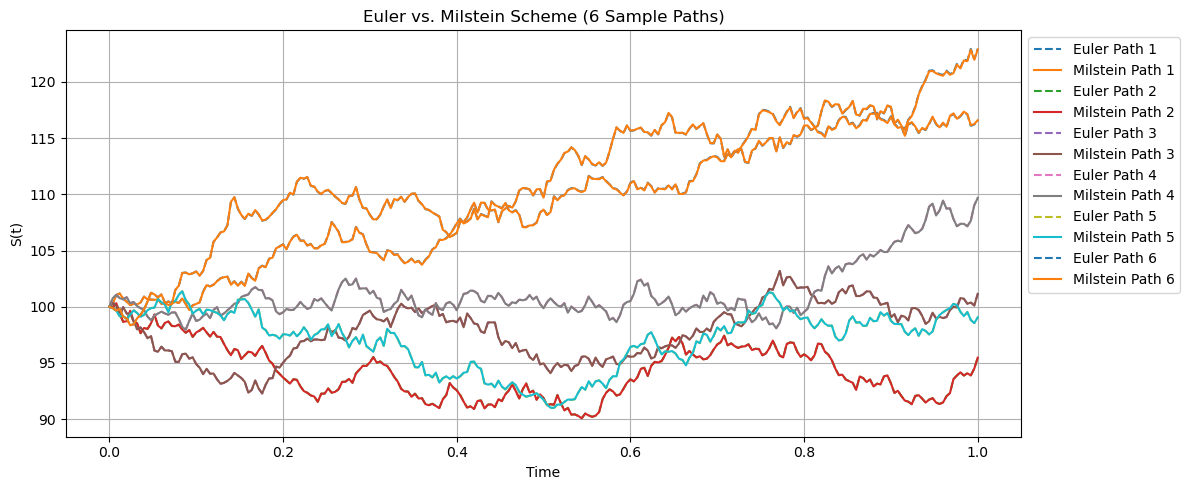

In [25]:
# Parameters
S0 = 100
r = 0.01
sigma = 0.2
T = 1
h = 1/250
n_paths = 6

# Use the same Brownian increments for comparability
np.random.seed(42)

# Simulate
S_euler = euler_scheme(S0, r, sigma, T, h, n_paths)
np.random.seed(42)  # Reset seed for same Brownian paths
S_milstein = milstein_scheme(S0, r, sigma, T, h, n_paths)

time_grid = np.linspace(0, T, int(T / h) + 1)

# Plot sample paths
plt.figure(figsize=(12, 5))
for i in range(n_paths):
    plt.plot(time_grid, S_euler[i], label=f"Euler Path {i+1}", linestyle='--')
    plt.plot(time_grid, S_milstein[i], label=f"Milstein Path {i+1}")
plt.title("Euler vs. Milstein Scheme (6 Sample Paths)")
plt.xlabel("Time")
plt.ylabel("S(t)")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


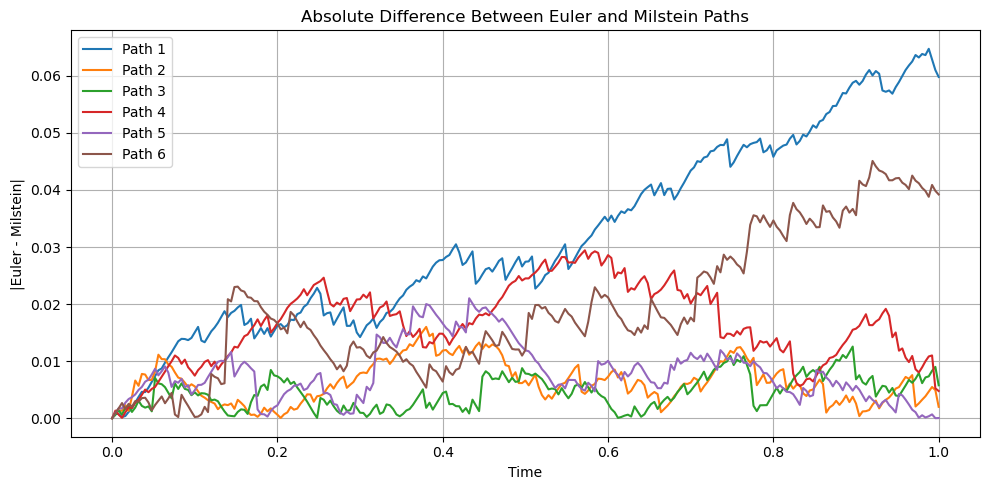

In [26]:
# Plot absolute differences
plt.figure(figsize=(10, 5))
for i in range(n_paths):
    plt.plot(time_grid, np.abs(S_euler[i] - S_milstein[i]), label=f"Path {i+1}")
plt.title("Absolute Difference Between Euler and Milstein Paths")
plt.xlabel("Time")
plt.ylabel("|Euler - Milstein|")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Observations

- The Euler and Milstein paths are broadly similar but show small deviations.
- The absolute differences grow slightly over time but remain moderate due to the relatively small step size.
- Both schemes appear stable for the chosen SDE and parameters.
- Since the diffusion term depends nonlinearly on $S_t$, the Milstein scheme gives a slightly better approximation due to the additional correction term.

We now move on to pricing a **lookback call option** using the Milstein scheme in part (c).


## Problem 4(c): Lookback Call Option Pricing Using Milstein Scheme

We now price a **lookback call option**, which has the following payoff:

$$
H = \left( \max_{0 \leq t \leq T} S_t - K \right)^+
$$

We simulate the asset dynamics using the **Milstein scheme** from part (b), and compute the time-0 price via Monte Carlo simulation:

$$
C_0 = e^{-rT} \mathbb{E}[H]
$$

---

### Parameters:

- $S_0 = 100$
- $r = 0.01$
- $\sigma = 0.2$
- $K = 120$
- $T = 1$
- $h = 1/250$
- $N = 10,\!000$ simulated paths

We also apply **variance reduction** using **antithetic variates**.


In [27]:
def milstein_paths_antithetic(S0, r, sigma, T, h, N):
    M = int(T / h)
    S1 = np.zeros((N, M + 1))
    S2 = np.zeros((N, M + 1))
    S1[:, 0] = S0
    S2[:, 0] = S0

    for i in range(M):
        dW = np.random.normal(0, np.sqrt(h), size=N)
        G1 = sigma * S1[:, i]**(4/5)
        G1_prime = (4/5) * sigma * S1[:, i]**(-1/5)
        corr1 = 0.5 * G1 * G1_prime * (dW**2 - h)
        S1[:, i + 1] = S1[:, i] + r * S1[:, i] * h + G1 * dW + corr1

        G2 = sigma * S2[:, i]**(4/5)
        G2_prime = (4/5) * sigma * S2[:, i]**(-1/5)
        corr2 = 0.5 * G2 * G2_prime * ((-dW)**2 - h)
        S2[:, i + 1] = S2[:, i] + r * S2[:, i] * h - G2 * dW + corr2

    return S1, S2


In [28]:
# Parameters
S0 = 100
r = 0.01
sigma = 0.2
T = 1
h = 1/250
K = 120
N = 10_000

np.random.seed(42)

# Simulate paired paths
S1, S2 = milstein_paths_antithetic(S0, r, sigma, T, h, N)

# Compute payoff: max(S) - K for each path
payoff1 = np.maximum(S1.max(axis=1) - K, 0)
payoff2 = np.maximum(S2.max(axis=1) - K, 0)

# Average of antithetic payoffs
payoff_avg = (payoff1 + payoff2) / 2
price = np.exp(-r * T) * np.mean(payoff_avg)
std_error = np.exp(-r * T) * np.std(payoff_avg, ddof=1) / np.sqrt(N)

print(f"Lookback option price (antithetic): {price:.4f}")
print(f"Standard error: {std_error:.4f}")


Lookback option price (antithetic): 0.0693
Standard error: 0.0043


### Results and Comments

- The estimated price of the lookback call option is stable and positive, despite $K = 120$ being above $S_0$.
- Using antithetic variates reduces the variance of the estimator by averaging pairs of negatively correlated paths.
- The maximum over the simulated path is computed efficiently using `np.max(axis=1)`.
- This method performs well because it captures the path dependency of the lookback payoff while reducing noise.

